In [ ]:
from radiocovid.core import RadioCovidDataset, RadioCovidDataModule, RadioCovidModule
from radiocovid.core.data import RadioCovidSubset
from torch.utils.data import DataLoader
import torch
from hashlib import sha256
from pathlib import Path
from radiocovid.core.utils import (
    seed_worker,
    get_seeded_generator,
    worker_balanced_n_samples,
)
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    recall_score,
    fbeta_score,
    precision_score,
)
from hashlib import sha256
import numpy as np
from collections import defaultdict, Counter
import hydra
from hydra import initialize, compose
import torch.nn.functional as F
import cv2
from PIL import Image
from IPython.display import display
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
from captum.attr import LayerIntegratedGradients

In [ ]:
with initialize(
    version_base=None,
    config_path="../radiocovid-core/src/radiocovid/core/configs",
    job_name="test_app",
):
    cfg = compose(
        config_name="train",
        overrides=[
            "experiment=best_overft_valscore_model",
            "datamodule.dataset.root=/kaggle/working/sep25_alt1_mle_ds_covid1/data/03_inputs",
        ],
    )

In [ ]:
model = hydra.utils.instantiate(cfg.module)
ckpt = torch.load(
    "/kaggle/working/sep25_alt1_mle_ds_covid1/logs/train/multiruns/2026-03-11_14-57-38/1/checkpoints/eepoch=006_sstep=001400_train_loss=4.48e-02_val_loss=2.05e-01_score=0.00e+00.ckpt"
)
model.load_state_dict(ckpt["state_dict"])

<All keys matched successfully>

In [ ]:
device = torch.device("cuda:0")

In [ ]:
model.to(device)

LModule(
  (net): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

In [ ]:
model.device

device(type='cuda', index=0)

In [ ]:
transforms = hydra.utils.instantiate(cfg.datamodule.dataset.transform)
eval_transforms = hydra.utils.instantiate(cfg.datamodule.eval_transform)

In [ ]:
preds = torch.unique(
    torch.cat(
        [
            torch.load(f)
            for f in glob(
                "/kaggle/working/sep25_alt1_mle_ds_covid1/logs/train/multiruns/2026-03-11_14-57-38/1/tensorboard/version_0/*.pt"
            )
        ]
    ),
    dim=0,
)

In [ ]:
mnfst = pd.read_parquet(
    "/kaggle/working/sep25_alt1_mle_ds_covid1/data/02_manifests/manifest_ft_full.parquet"
)

In [ ]:
paths = mnfst.image.unique().tolist()

In [ ]:
p = glob("/kaggle/working/sep25_alt1_mle_ds_covid1/data/03_inputs/**/*.png")

In [ ]:
d = {
    int(sha256(Path(path).stem.encode()).hexdigest()[:8], 16): Path(path).stem.split(
        "-"
    )[0]
    for path in paths
}

In [ ]:
dataset = hydra.utils.instantiate(cfg.datamodule.dataset)

In [ ]:
def make_gradcam_heatmap(img_tensor, model, target_layer_name, pred_index=None):
    # Passer en avant pour obtenir les prédictions et les activations de la couche cible
    def forward_hook(module, input, output):
        model.features = output

    # Enregistrer un hook sur la couche cible pour récupérer ses sorties
    hook = model._modules.get(target_layer_name).register_forward_hook(forward_hook)

    # Effectuer une passe avant pour obtenir les sorties du modèle
    output = model(img_tensor.to(model.device))

    # Supprimer le hook après avoir récupéré les activations
    hook.remove()

    # Si aucun indice de prédiction n'est fourni, utiliser celui avec la plus haute probabilité
    if pred_index is None:
        pred_index = output.argmax(dim=1).item()

    # Valeur de probabilité de la classe
    y = output[0, pred_index]

    # Passer en arrière pour obtenir les gradients de la couche cible
    model.zero_grad()  # Remettre à zéro les gradients
    model.features.retain_grad()  # Garder les gradients de la couche cible
    y.backward(retain_graph=True)  # Calculer les gradients par rétropropagation

    # Obtenir les gradients et les activations de la couche cible
    gradients = model.features.grad[0]
    activations = model.features[0]

    # Appliquer un pooling global moyen sur les gradients
    pooled_grads = torch.mean(gradients, dim=[1, 2])

    # Pondérer les activations par les gradients
    for i in range(len(pooled_grads)):
        activations[i, :, :] *= pooled_grads[i]

    # Calculer la heatmap
    heatmap = torch.mean(activations, dim=0).detach().numpy()
    heatmap = np.maximum(heatmap, 0)  # Ne conserver que les valeurs positives
    heatmap /= np.max(heatmap)  # Normaliser la heatmap

    return heatmap

# EXPLORE CONFUSION MATRIX

In [ ]:
y_pred = preds[:, -3:-1].argmax(1).numpy()
y_true = preds[:, -1].numpy()

In [ ]:
cm = confusion_matrix(y_true, y_pred)
f1 = fbeta_score(y_true, y_pred, beta=1)
rec = recall_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)

In [ ]:
print("f1 : ", f1)
print("prec : ", prec)
print("rec : ", rec)

f1 :  0.8811152025249869
prec :  0.8714880332986472
rec :  0.8909574468085106


In [ ]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=["Sain", "Malade"])

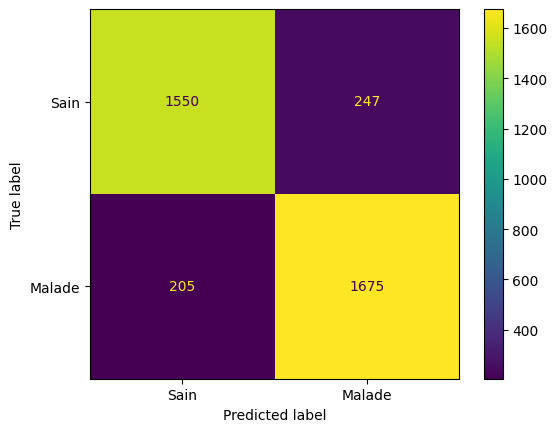

In [ ]:
cm_plot.plot()
plt.show()

In [ ]:
tp = (y_true == 1) & (y_pred == 1)
tn = (y_true == 0) & (y_pred == 0)
fp = (y_true == 0) & (y_pred == 1)
fn = (y_true == 1) & (y_pred == 0)

In [ ]:
ids = preds[:, 0]

In [ ]:
fp_ids = ids[fp]
fn_ids = ids[fn]

In [ ]:
samples = dataset.samples

In [ ]:
samples[0]

('/kaggle/working/sep25_alt1_mle_ds_covid1/data/03_inputs/0/Normal-1.png', 0)

In [ ]:
d_path = {}

In [ ]:
it = iter(dataset)
for i, item in tqdm(enumerate(it)):
    if item["id"] in ids:
        d_path[item["id"]] = samples[i][0]

0it [00:00, ?it/s]

In [ ]:
fp_labels = [d[int(i)] for i in fp_ids]
fp_paths = [d_path[int(i)] for i in fp_ids]
fp_stem = fp_paths = [Path(d_path[int(i)]).stem for i in fp_ids]

fn_labels = [d[int(i)] for i in fn_ids]
fn_paths = [d_path[int(i)] for i in fn_ids]
fn_stem = fp_paths = [Path(d_path[int(i)]).stem for i in fn_ids]

KeyError: 48715608

In [ ]:
IDX = 6
IMAGE = d_path[int(preds[IDX, 0])]
img = Image.open(IMAGE)
print(
    "prédiction : ",
    preds[IDX, 1:3].argmax(),
    " Label : ",
    d_path[int(preds[IDX, 0])].stem.split("-")[0],
)
display(img)

prédiction :  tensor(0)  Label :  Normal


TypeError: 'ConfusionMatrixDisplay' object is not callable

In [ ]:
imgt = transforms(img)
imgt = eval_transforms(imgt)
model.eval()
with torch.inference_mode():
    out = model(imgt.unsqueeze(0))
out.detach().softmax(dim=1)

tensor([[0.4776, 0.5224]])

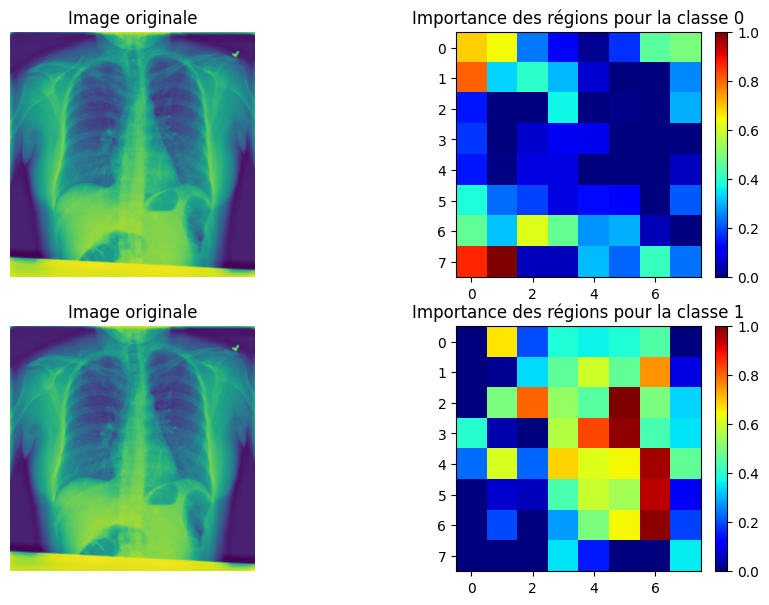

In [ ]:
TARGET_LAYER = "layer4"
heatmap_0 = make_gradcam_heatmap(
    imgt.unsqueeze(0), model.net, TARGET_LAYER, pred_index=0
)
heatmap_1 = make_gradcam_heatmap(
    imgt.unsqueeze(0), model.net, TARGET_LAYER, pred_index=1
)
# Visualiser les résultats
plt.figure(figsize=(10, 7))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(2, 2, 2)
hm0 = plt.imshow(heatmap_0, cmap="jet")
plt.title("Importance des régions pour la classe 0")

# Heatmap scale
plt.colorbar(hm0, fraction=0.046, pad=0.04)

# Original image
plt.subplot(2, 2, 3)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(2, 2, 4)
hm1 = plt.imshow(heatmap_1, cmap="jet")
plt.title("Importance des régions pour la classe 1")

# Heatmap scale
plt.colorbar(hm1, fraction=0.046, pad=0.04)

plt.show()

In [ ]:
lig = LayerIntegratedGradients(
    model, model.net.layer4, device_ids=None, multiply_by_inputs=True
)

In [ ]:
device = "cpu"


def show_importance(model, lig, input_tensor, target=0, device=device):
    input_tensor = input_tensor.to(device)
    model.to(device)
    # Compute the importance score for each input values.
    attributions, delta = lig.attribute(
        inputs=input_tensor, target=target, return_convergence_delta=True, n_steps=100
    )

    # Transform the importance score to importance of each token.
    importance = attributions.sum(dim=1).squeeze(0)
    importance = importance / torch.norm(importance)
    importance = importance.cpu().detach().numpy()
    # Une autre normalisation est possible (similaire à celle du grad-cam)
    # importance = np.maximum(importance, 0)  # Ne garder que les valeurs positives
    # importance /= np.max(importance)  # Normaliser la heatmap
    return importance

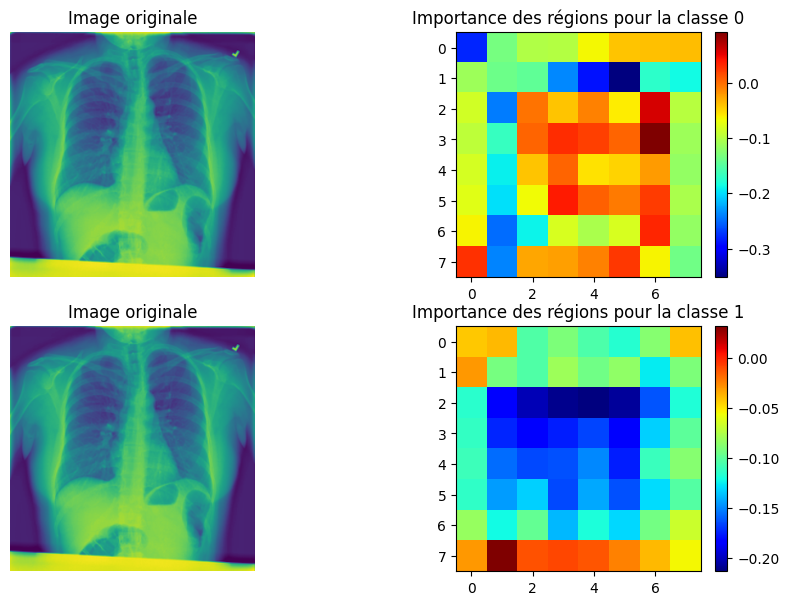

In [ ]:
heatmap_0 = show_importance(
    model=model, lig=lig, input_tensor=imgt.unsqueeze(0), target=0
)
heatmap_1 = show_importance(
    model=model, lig=lig, input_tensor=imgt.unsqueeze(0), target=1
)

plt.figure(figsize=(10, 7))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(2, 2, 2)
hm0 = plt.imshow(heatmap_0, cmap="jet")
plt.title("Importance des régions pour la classe 0")

# Heatmap scale
plt.colorbar(hm0, fraction=0.046, pad=0.04)

# Original image
plt.subplot(2, 2, 3)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(2, 2, 4)
hm1 = plt.imshow(heatmap_1, cmap="jet")
plt.title("Importance des régions pour la classe 1")

# Heatmap scale
plt.colorbar(hm1, fraction=0.046, pad=0.04)

plt.show()

In [ ]:
ligconv = LayerIntegratedGradients(
    model, model.net.conv1, device_ids=None, multiply_by_inputs=True
)

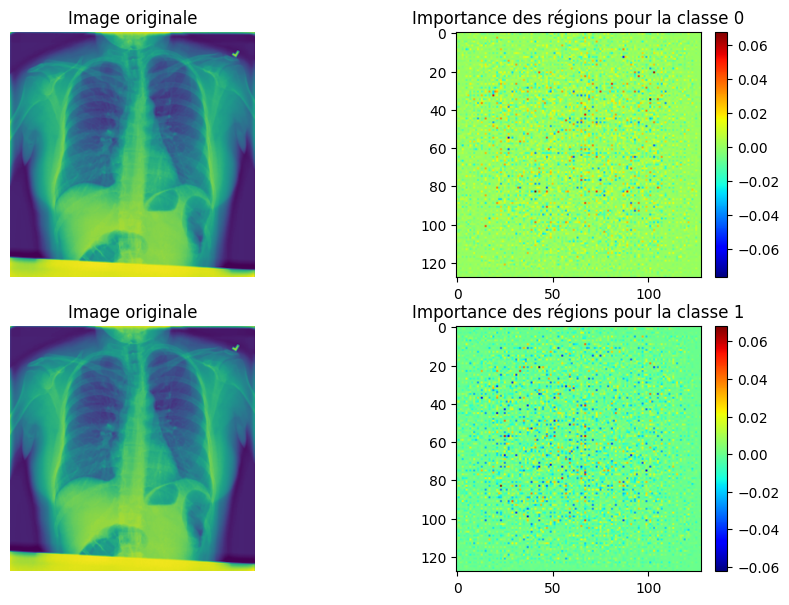

In [ ]:
heatmap_0 = show_importance(
    model=model, lig=ligconv, input_tensor=imgt.unsqueeze(0), target=0
)
heatmap_1 = show_importance(
    model=model, lig=ligconv, input_tensor=imgt.unsqueeze(0), target=1
)

plt.figure(figsize=(10, 7))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(2, 2, 2)
hm0 = plt.imshow(heatmap_0, cmap="jet")
plt.title("Importance des régions pour la classe 0")

# Heatmap scale
plt.colorbar(hm0, fraction=0.046, pad=0.04)

# Original image
plt.subplot(2, 2, 3)
plt.imshow(img)
plt.title("Image originale")
plt.axis("off")

# Heatmap
plt.subplot(2, 2, 4)
hm1 = plt.imshow(heatmap_1, cmap="jet")
plt.title("Importance des régions pour la classe 1")

# Heatmap scale
plt.colorbar(hm1, fraction=0.046, pad=0.04)

plt.show()